# 上市公司年报关键词分析：通威股份（600438）

本 notebook 对应项目 `P03e`。当前数据选择通威股份有限公司（股票代码：600438），年度为 2022、2023、2024 年年度报告。第一部分记录从巨潮资讯网下载 PDF 并提取 MD&A 正文的流程；第二部分完成文本清洗和字数验证。

建议在 VS Code 中选择 kernel：`Python 3.11.15 (P03e)`。本项目已在 `.venv` 中使用 Python 3.11.15 配置运行环境。

## AI 使用说明（简要）

本项目开发过程中使用 AI 辅助完成数据获取、PDF 文本提取、清洗规则设计、词频/TF-IDF/风险词汇分析、同行业公司比较、README 与 Quarto 电子书结构整理。主要向 AI 提问的问题包括：如何从巨潮资讯网获取年报 PDF、如何提取 MD&A 章节、如何处理页眉页脚和表格噪音、如何选择行业关键词和风险词表、如何比较同行业公司文本风格。

对 AI 建议的取舍：采用了 `pdfplumber + jieba + scikit-learn + matplotlib` 的技术路线，但章节边界、停用词、行业关键词、风险词表和结论解释均结合人工检查进行了调整。AI 难以完全解决的问题包括巨潮接口参数试错、PDF 正文边界核查、中文停用词取舍，以及避免把词频变化过度解释为因果关系。


## 0. 环境检查

确认 notebook 使用的是项目虚拟环境，并检查第一步需要的 `requests`、`pdfplumber` 是否可用。若缺少依赖，可在终端执行：

```powershell
.\.venv\Scripts\python.exe -m pip install requests pdfplumber ipykernel
```

In [1]:
from pathlib import Path
import importlib.util
import subprocess
import sys

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
RAW_REPORT_DIR = DATA_DIR / "raw_reports"
CLEAN_DIR = DATA_DIR / "cleaned"
FIG_DIR = PROJECT_ROOT / "figs"

for d in [DATA_DIR, RAW_REPORT_DIR, CLEAN_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

required_packages = {
    "requests": "requests",
    "pdfplumber": "pdfplumber",
    "jieba": "jieba",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
}

def ensure_package(import_name: str, pip_name: str):
    if importlib.util.find_spec(import_name) is not None:
        return True
    print(f"缺少 {import_name}，正在安装 {pip_name} 到当前解释器：{sys.executable}")
    try:
        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            "-i",
            "https://pypi.tuna.tsinghua.edu.cn/simple",
            "--timeout",
            "120",
            pip_name,
        ])
    except Exception as exc:
        print(f"安装 {pip_name} 失败：{exc}")
        print("请在 VS Code 右上角选择 kernel：Python 3.11.15 (P03e)，然后 Restart Kernel 后重新运行。")
        return False
    return importlib.util.find_spec(import_name) is not None

package_status = {name: ensure_package(name, pip_name) for name, pip_name in required_packages.items()}

print("Python:", sys.version)
print("解释器:", sys.executable)
print("项目目录:", PROJECT_ROOT)
print(package_status)


Python: 3.11.15 | packaged by conda-forge | (main, Mar  5 2026, 16:36:00) [MSC v.1944 64 bit (AMD64)]
解释器: d:\anaconda3\envs\dsfin_py311\python.exe
项目目录: c:\Users\ZhuanZ1\Desktop\P03e
{'requests': True, 'pdfplumber': True, 'jieba': True, 'sklearn': True, 'matplotlib': True}


## 1. 获取数据：下载 PDF 并提取 MD&A

数据来源为巨潮资讯网年度报告 PDF。这里使用通威股份有限公司（600438）最近三个完整年度报告：

- 2022 年年度报告：http://static.cninfo.com.cn/finalpage/2023-04-25/1216551537.PDF
- 2023 年年度报告：http://static.cninfo.com.cn/finalpage/2024-04-30/1219915221.PDF
- 2024 年年度报告：http://static.cninfo.com.cn/finalpage/2025-04-30/1223425884.PDF

本步骤做两件事：

1. 将 PDF 下载到 `data/raw_reports/`。
2. 使用 `pdfplumber` 提取“第三节 管理层讨论与分析”至“第四节 公司治理”之前的正文，保存为 `data/600438_{year}_mda.txt`。

如果某年 PDF 为扫描版，`pdfplumber` 提取出的文字会很少；这种情况应记录为需要 OCR，本题可跳过该年份并说明原因。

In [2]:
reports = {
    "2022": "http://static.cninfo.com.cn/finalpage/2023-04-25/1216551537.PDF",
    "2023": "http://static.cninfo.com.cn/finalpage/2024-04-30/1219915221.PDF",
    "2024": "http://static.cninfo.com.cn/finalpage/2025-04-30/1223425884.PDF",
}

import requests

headers = {
    "User-Agent": "Mozilla/5.0",
    "Referer": "http://www.cninfo.com.cn/",
}

for year, url in reports.items():
    pdf_path = RAW_REPORT_DIR / f"600438_{year}_annual_report.pdf"
    if pdf_path.exists() and pdf_path.stat().st_size > 100_000:
        print(f"{year}: PDF 已存在，跳过下载 -> {pdf_path}")
        continue
    response = requests.get(url, headers=headers, timeout=120)
    response.raise_for_status()
    pdf_path.write_bytes(response.content)
    print(f"{year}: 下载完成，大小 {len(response.content):,} bytes -> {pdf_path}")

2022: PDF 已存在，跳过下载 -> c:\Users\ZhuanZ1\Desktop\P03e\data\raw_reports\600438_2022_annual_report.pdf
2023: PDF 已存在，跳过下载 -> c:\Users\ZhuanZ1\Desktop\P03e\data\raw_reports\600438_2023_annual_report.pdf
2024: PDF 已存在，跳过下载 -> c:\Users\ZhuanZ1\Desktop\P03e\data\raw_reports\600438_2024_annual_report.pdf


In [3]:
import re
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("pdfplumber") is None:
    print("当前 kernel 缺少 pdfplumber，正在尝试安装。")
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-i",
        "https://pypi.tuna.tsinghua.edu.cn/simple",
        "--timeout",
        "120",
        "pdfplumber",
    ])

import pdfplumber

COMPANY_NAME = "通威股份有限公司"
STOCK_CODE = "600438"
START_TITLE = "第三节管理层讨论与分析"
END_TITLE = "第四节公司治理"

def compact(text: str) -> str:
    return "".join(text.split())

def loose_pattern(text: str) -> re.Pattern:
    return re.compile(r"\s*".join(re.escape(ch) for ch in text))

def normalize_text(text: str) -> str:
    text = text.replace("\r\n", "\n").replace("\r", "\n")
    text = re.sub(r"[ \t]+\n", "\n", text)
    text = re.sub(r"\n{3,}", "\n\n", text)
    return text.strip()

def extract_mda_from_pdf(pdf_path: Path) -> tuple[str, tuple[int, int]]:
    page_texts = []
    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            page_texts.append(page.extract_text(x_tolerance=1.5, y_tolerance=3) or "")

    total_chars = sum(len(t.strip()) for t in page_texts)
    if total_chars < 1000:
        raise ValueError(f"{pdf_path.name} 提取文字过少，可能是扫描版 PDF，需要 OCR。")

    start_candidates = [i for i, t in enumerate(page_texts) if START_TITLE in compact(t)]
    end_candidates = [i for i, t in enumerate(page_texts) if END_TITLE in compact(t)]
    if not start_candidates or not end_candidates:
        raise ValueError(f"{pdf_path.name} 未找到章节边界，请人工检查目录/标题。")

    # 前几页通常是目录或重要提示中的引用，正文标题一般在第 5 页之后。
    start_page = next((i for i in start_candidates if i >= 4), start_candidates[-1])
    end_page = next(i for i in end_candidates if i > start_page)
    section_text = "\n\n".join(page_texts[start_page:end_page + 1])

    start_match = list(loose_pattern(START_TITLE).finditer(section_text))
    start = start_match[-1].start() if start_match else 0
    end_match = loose_pattern(END_TITLE).search(section_text, start + 1)
    end = end_match.start() if end_match else len(section_text)
    return normalize_text(section_text[start:end]), (start_page + 1, end_page + 1)

for year in reports:
    pdf_path = RAW_REPORT_DIR / f"600438_{year}_annual_report.pdf"
    out_path = DATA_DIR / f"600438_{year}_mda.txt"
    mda_text, page_range = extract_mda_from_pdf(pdf_path)
    header = (
        "封面信息\n"
        f"公司名称：{COMPANY_NAME}\n"
        f"股票代码：{STOCK_CODE}\n"
        f"报告年度：{year} 年年度报告\n"
        "公告来源：巨潮资讯网\n"
        f"原始 PDF：{reports[year]}\n"
        "提取说明：使用 pdfplumber 提取；PDF 为文本型，无需 OCR。\n\n"
    )
    out_path.write_text(header + mda_text + "\n", encoding="utf-8")
    print(f"{year}: 提取页段 {page_range[0]}-{page_range[1]}，字符数 {len(mda_text):,} -> {out_path}")


2022: 提取页段 9-35，字符数 34,920 -> c:\Users\ZhuanZ1\Desktop\P03e\data\600438_2022_mda.txt
2023: 提取页段 9-39，字符数 37,029 -> c:\Users\ZhuanZ1\Desktop\P03e\data\600438_2023_mda.txt
2024: 提取页段 10-40，字符数 36,862 -> c:\Users\ZhuanZ1\Desktop\P03e\data\600438_2024_mda.txt


## 2. 数据清洗

清洗目标：

- 去除页眉、页脚、页码。
- 去除表格中以数字为主、对关键词分析贡献较低的行。
- 合并 PDF 抽取造成的句中断行，清理多余空格和空行。
- 验证三年文本字数是否合理。若清洗后中文字符数极少，通常意味着 PDF 提取失败或需要 OCR。

清洗后的文件保存到 `data/cleaned/`，字数检查结果保存到 `data/text_length_check.csv`。

In [4]:
import csv
import re

SECTION_TITLE = "第三节 管理层讨论与分析"

def strip_to_body(text: str) -> str:
    idx = text.find(SECTION_TITLE)
    return text[idx:] if idx >= 0 else text

def is_page_noise(line: str) -> bool:
    s = line.strip()
    if not s:
        return False
    if re.fullmatch(r"[-–—_\s]*\d+[-–—_\s]*", s):
        return True
    if re.fullmatch(r"\d+\s*/\s*\d+", s):
        return True
    if re.fullmatch(r"(通威股份有限公司\s*)?20\d{2}\s*年年度报告", s):
        return True
    if re.fullmatch(r"第\s*\d+\s*页\s*/\s*共\s*\d+\s*页", s):
        return True
    if re.fullmatch(r"[.·。\-—_\s]{8,}", s):
        return True
    return False

def is_table_noise(line: str) -> bool:
    s = line.strip()
    if not s:
        return False
    if re.fullmatch(r"[□√☑\s]*适用[□√☑\s]*不适用[□√☑\s]*", s):
        return True
    if re.search(r"单位[:：].*(元|万元|亿元).*币种[:：]", s):
        return True
    no_space = re.sub(r"\s+", "", s)
    if len(no_space) < 12:
        return False
    chinese = len(re.findall(r"[\u4e00-\u9fff]", no_space))
    digits = len(re.findall(r"[0-9０-９]", no_space))
    numeric_punct = len(re.findall(r"[0-9０-９,，.．%％+\-－()/（）]", no_space))
    ratio = numeric_punct / max(len(no_space), 1)
    if digits >= 8 and chinese <= 6:
        return True
    if ratio >= 0.58 and chinese <= 12:
        return True
    if re.fullmatch(r"(项目|科目|产品|地区|行业|分部|合计|小计|本期|上期|上年同期|金额|比例|同比|增减|原因|说明)[\u4e00-\u9fff\s%％（）()、/]+", s) and len(s) <= 45:
        return True
    return False

def is_heading(line: str) -> bool:
    return bool(re.match(r"^(第[一二三四五六七八九十]+节|[一二三四五六七八九十]+、|（[一二三四五六七八九十]+）|\([一二三四五六七八九十]+\)|\d+[、.．])", line.strip()))

def should_join(prev: str, cur: str) -> bool:
    if is_heading(cur):
        return False
    if re.search(r"[。！？；：]$", prev):
        return False
    if re.search(r"[:：]$", prev) and len(prev) < 24:
        return False
    return True

def joiner(prev: str, cur: str) -> str:
    if re.search(r"[A-Za-z0-9]$", prev) and re.match(r"^[A-Za-z0-9]", cur):
        return prev + " " + cur
    return prev + cur

def clean_text(raw: str) -> tuple[str, dict]:
    body = strip_to_body(raw)
    body = body.replace("\ufeff", "").replace("\f", "\n").replace("\u3000", " ")
    body = re.sub(r"[\t\r]+", " ", body)

    kept = []
    removed_page = 0
    removed_table = 0
    for line in body.splitlines():
        line = re.sub(r"\s+", " ", line).strip()
        if not line:
            kept.append("")
            continue
        if is_page_noise(line):
            removed_page += 1
            continue
        if is_table_noise(line):
            removed_table += 1
            continue
        kept.append(line)

    paragraphs = []
    buf = ""
    for line in kept:
        if not line:
            if buf:
                paragraphs.append(buf)
                buf = ""
            continue
        if is_heading(line):
            if buf:
                paragraphs.append(buf)
            paragraphs.append(line)
            buf = ""
            continue
        if not buf:
            buf = line
        elif should_join(buf, line):
            buf = joiner(buf, line)
        else:
            paragraphs.append(buf)
            buf = line
    if buf:
        paragraphs.append(buf)

    cleaned = "\n".join(p.strip() for p in paragraphs if p.strip())
    cleaned = re.sub(r"\n{3,}", "\n\n", cleaned).strip() + "\n"
    return cleaned, {"removed_page_lines": removed_page, "removed_table_lines": removed_table}

def count_chinese(text: str) -> int:
    return len(re.findall(r"[\u4e00-\u9fff]", text))


In [5]:
stats = []
for src in sorted(DATA_DIR.glob("600438_*_mda.txt")):
    year = src.stem.split("_")[1]
    raw = src.read_text(encoding="utf-8")
    cleaned, info = clean_text(raw)
    dst = CLEAN_DIR / f"600438_{year}_mda_clean.txt"
    dst.write_text(cleaned, encoding="utf-8")

    raw_body = strip_to_body(raw)
    chinese_chars = count_chinese(cleaned)
    status = "正常" if chinese_chars >= 10_000 else "异常：字数偏少，需检查 PDF 提取或 OCR"
    stats.append({
        "year": year,
        "raw_chars": len(raw_body),
        "clean_chars": len(cleaned),
        "clean_chinese_chars": chinese_chars,
        "removed_page_lines": info["removed_page_lines"],
        "removed_table_lines": info["removed_table_lines"],
        "status": status,
        "file": str(dst),
    })

stats_path = DATA_DIR / "text_length_check.csv"
with stats_path.open("w", encoding="utf-8-sig", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=list(stats[0].keys()))
    writer.writeheader()
    writer.writerows(stats)

for row in stats:
    print(
        f"{row['year']}: 原始 {row['raw_chars']:,} 字符，清洗后 {row['clean_chars']:,} 字符，"
        f"中文字符 {row['clean_chinese_chars']:,}，移除页眉/页码 {row['removed_page_lines']} 行，"
        f"移除表格数字 {row['removed_table_lines']} 行，判断：{row['status']}"
    )
print("字数检查表：", stats_path)

2022: 原始 34,921 字符，清洗后 28,616 字符，中文字符 21,908，移除页眉/页码 52 行，移除表格数字 163 行，判断：正常
2023: 原始 37,030 字符，清洗后 30,626 字符，中文字符 23,503，移除页眉/页码 60 行，移除表格数字 169 行，判断：正常
2024: 原始 36,863 字符，清洗后 30,482 字符，中文字符 23,448，移除页眉/页码 60 行，移除表格数字 166 行，判断：正常
字数检查表： c:\Users\ZhuanZ1\Desktop\P03e\data\text_length_check.csv


### 字数验证结果

| 年度 | 原始正文字符数 | 清洗后字符数 | 清洗后中文字符数 | 页眉页脚/页码行 | 表格数字行 | 判断 |
|---|---:|---:|---:|---:|---:|---|
| 2022 | 34921 | 28616 | 21908 | 52 | 163 | 正常 |
| 2023 | 37030 | 30626 | 23503 | 60 | 169 | 正常 |
| 2024 | 36863 | 30482 | 23448 | 60 | 166 | 正常 |

三年清洗后中文字符数都明显高于 10,000，且三年规模接近，说明本次 PDF 文本提取基本正常，没有出现“字数极少”的提取失败现象。后续做分词、TF-IDF 或风险词频统计时，建议优先使用 `data/cleaned/` 中的清洗版本。


## 3. 文本内容分析：词频与 TF-IDF

本步骤基于 `data/cleaned/` 中的清洗文本进行中文分词，分别计算三年文本的词频 Top 20 和 TF-IDF 关键词 Top 20。词频反映“报告中反复讨论什么”，TF-IDF 更强调“某一年相对其他年份更有区分度的词”。

输出文件：

- `data/word_freq_top20.csv`
- `data/tfidf_top20.csv`
- `figs/fig01_tfidf_comparison.png`
- `figs/fig01b_tfidf_heatmap.png`

Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\ZhuanZ1\AppData\Local\Temp\jieba.cache
Loading model cost 0.774 seconds.
Prefix dict has been built successfully.



词频 Top 20
2022: 1.光伏(122)；2.企业(89)；3.饲料(82)；4.技术(78)；5.组件(78)；6.养殖(58)；7.电池(58)；8.产能(53)；9.高纯晶硅(48)；10.全球(45)；11.成本(45)；12.研发(45)；13.产业链(44)；14.项目(43)；15.增长(39)；16.规模(39)；17.风险(38)；18.万吨(37)；19.优势(37)；20.太阳能电池(37)
2023: 1.光伏(129)；2.饲料(103)；3.技术(86)；4.组件(84)；5.产能(74)；6.企业(72)；7.养殖(69)；8.全球(63)；9.研发(54)；10.风险(53)；11.增长(50)；12.高纯晶硅(49)；13.电池(49)；14.成本(48)；15.期内(47)；16.项目(45)；17.产业链(40)；18.万吨(40)；19.产业(39)；20.优势(39)
2024: 1.光伏(131)；2.企业(94)；3.饲料(92)；4.技术(85)；5.全球(64)；6.养殖(62)；7.组件(61)；8.研发(59)；9.成本(58)；10.产业(55)；11.风险(52)；12.产能(46)；13.增长(45)；14.期内(45)；15.优势(40)；16.项目(40)；17.电池(38)；18.产业链(37)；19.规模(37)；20.模式(31)

TF-IDF Top 20
2022: 1.光伏(0.335664)；2.企业(0.24487)；3.饲料(0.225611)；4.组件(0.214605)；5.技术(0.214605)；6.养殖(0.159578)；7.电池(0.159578)；8.产能(0.145821)；9.高纯晶硅(0.132065)；10.成本(0.123811)；11.全球(0.123811)；12.研发(0.123811)；13.产业链(0.121059)；14.项目(0.118308)；15.增长(0.107303)；16.规模(0.107303)；17.风险(0.104551)；18.太阳能电池(0.1018)；19.优势(0.1018)；20.万吨(0.1018)
2023: 1.光伏(0.333534)；2.饲料(0.26631)；3.技术(0.222356)；4.组

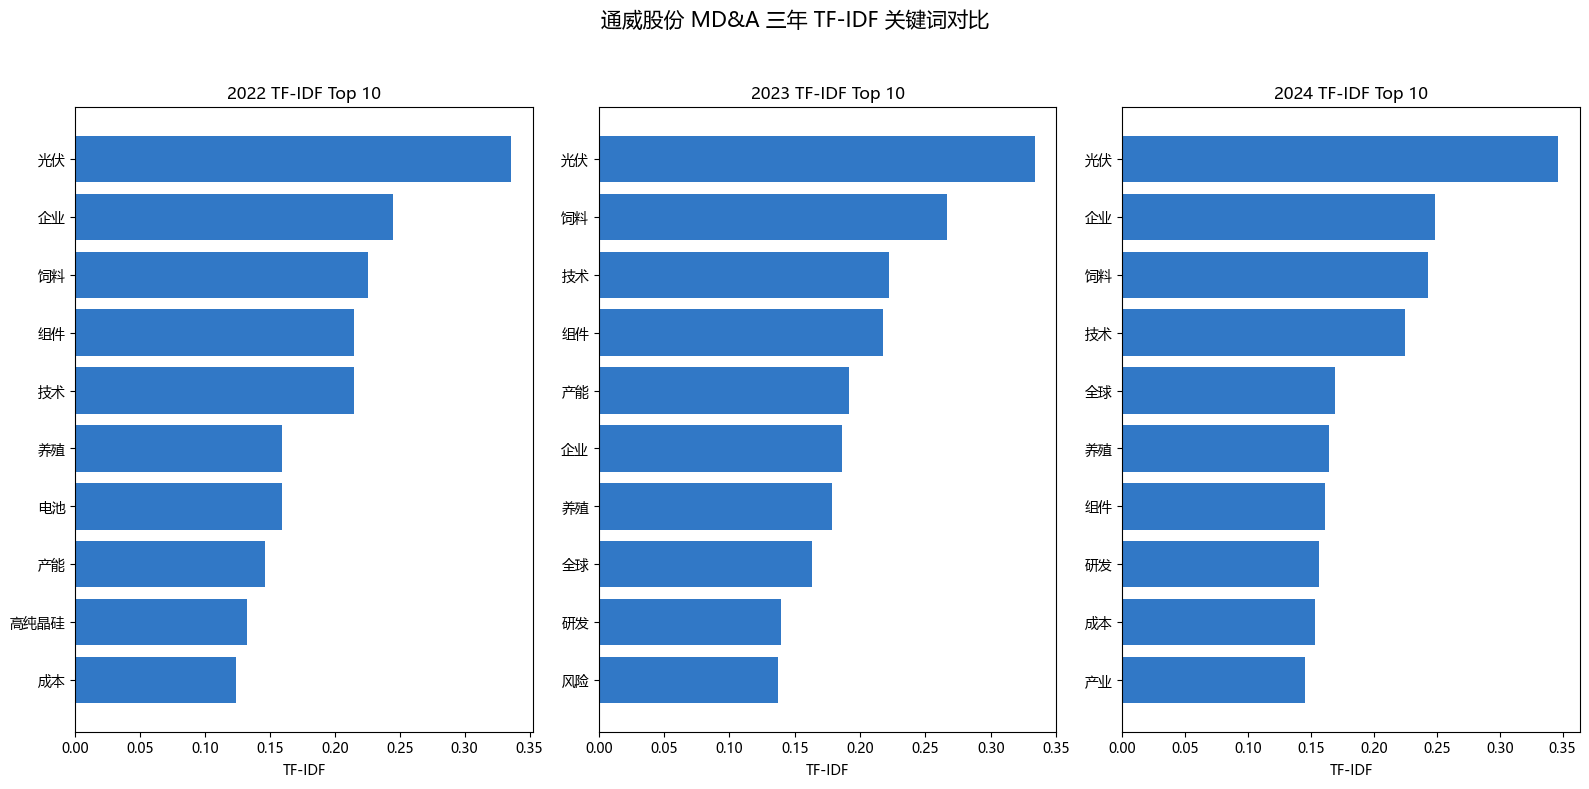

图已保存： c:\Users\ZhuanZ1\Desktop\P03e\figs\fig01_tfidf_comparison.png


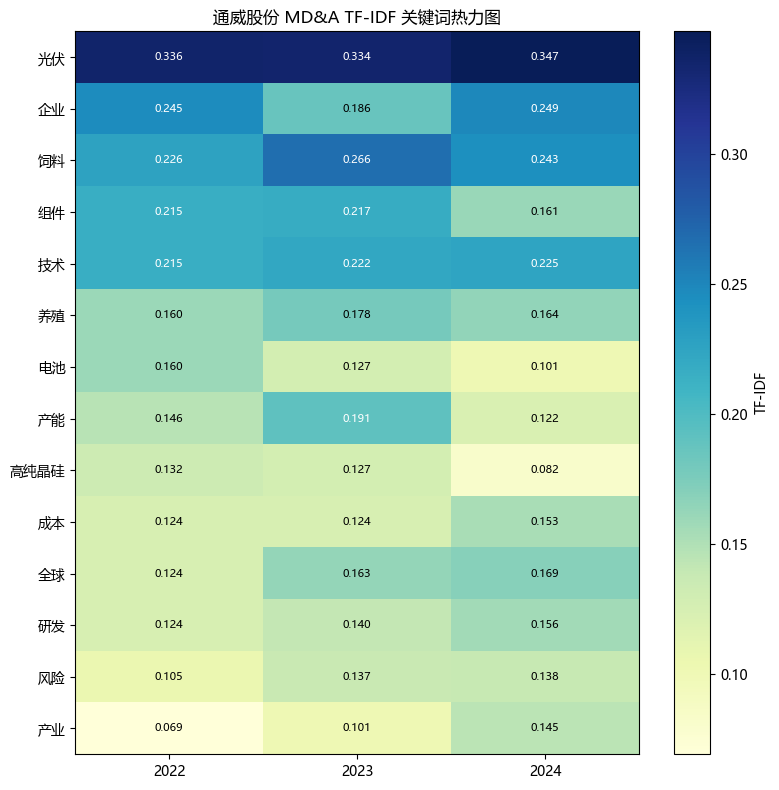

热力图已保存： c:\Users\ZhuanZ1\Desktop\P03e\figs\fig01b_tfidf_heatmap.png


In [6]:
from collections import Counter
import csv
import re

import jieba
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
from matplotlib import font_manager

# 配置中文字体，避免图中文字乱码。
def setup_chinese_font():
    candidates = ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "Source Han Sans SC", "Arial Unicode MS"]
    available = {f.name for f in font_manager.fontManager.ttflist}
    for font in candidates:
        if font in available:
            plt.rcParams["font.sans-serif"] = [font]
            break
    plt.rcParams["axes.unicode_minus"] = False

setup_chinese_font()

def draw_heatmap(matrix, row_labels, col_labels, title, cbar_label, path, cmap="YlGnBu", figsize=(9, 8)):
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(matrix, cmap=cmap, aspect="auto")
    ax.set_xticks(range(len(col_labels)))
    ax.set_xticklabels(col_labels)
    ax.set_yticks(range(len(row_labels)))
    ax.set_yticklabels(row_labels)
    ax.set_title(title)
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(cbar_label)

    max_value = max([max(row) for row in matrix]) if matrix else 0
    threshold = max_value * 0.55 if max_value else 0
    for i, row in enumerate(matrix):
        for j, value in enumerate(row):
            label = f"{value:.3f}" if isinstance(value, float) and value < 1 else f"{value:.0f}"
            color = "white" if value >= threshold else "black"
            ax.text(j, i, label, ha="center", va="center", color=color, fontsize=8)

    fig.tight_layout()
    fig.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    print("热力图已保存：", path)

YEARS = ["2022", "2023", "2024"]
clean_texts = {
    year: (CLEAN_DIR / f"600438_{year}_mda_clean.txt").read_text(encoding="utf-8")
    for year in YEARS
}

# 结合年报语境设置停用词，去掉高频但含义较弱的年报套话、单位和连接词。
stopwords = {
    "公司", "报告", "报告期", "年度", "本报告", "情况", "进行", "实现", "持续", "进一步", "相关", "主要", "方面",
    "以及", "同时", "通过", "不断", "提升", "保持", "由于", "其中", "具有", "形成", "推动", "加强", "开展",
    "业务", "产品", "市场", "行业", "客户", "生产", "销售", "发展", "建设", "管理", "经营", "影响", "同比",
    "万元", "亿元", "年度报告", "适用", "不适用", "股份", "通威", "通威股份", "上市公司", "有限", "有限责任",
    "一", "二", "三", "四", "五", "六", "七", "八", "九", "十", "年", "月", "日", "和", "与", "及", "等", "在", "对", "为", "以", "的", "了", "是", "将", "也", "并", "中", "上", "下"
}

# 让行业词尽量作为完整词出现。
for word in ["光伏", "高纯晶硅", "太阳能电池", "绿色能源", "绿色农业", "产业链", "电池片", "组件", "硅料", "饲料", "水产饲料", "成本控制", "现金流", "贸易壁垒", "技术研发", "不确定"]:
    jieba.add_word(word)

def tokenize(text: str) -> list[str]:
    tokens = []
    for token in jieba.lcut(text):
        token = token.strip()
        if not token:
            continue
        if token in stopwords:
            continue
        if len(token) < 2:
            continue
        if re.fullmatch(r"[0-9０-９.,，.%％/\-]+", token):
            continue
        if not re.search(r"[\u4e00-\u9fffA-Za-z]", token):
            continue
        tokens.append(token)
    return tokens

tokens_by_year = {year: tokenize(text) for year, text in clean_texts.items()}
freq_by_year = {year: Counter(tokens) for year, tokens in tokens_by_year.items()}

word_freq_rows = []
for year in YEARS:
    for rank, (word, count) in enumerate(freq_by_year[year].most_common(20), start=1):
        word_freq_rows.append({"year": year, "rank": rank, "word": word, "count": count})

with (DATA_DIR / "word_freq_top20.csv").open("w", encoding="utf-8-sig", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["year", "rank", "word", "count"])
    writer.writeheader()
    writer.writerows(word_freq_rows)

vectorizer = TfidfVectorizer(
    tokenizer=tokenize,
    token_pattern=None,
    lowercase=False,
    min_df=1,
)
tfidf_matrix = vectorizer.fit_transform([clean_texts[year] for year in YEARS])
feature_names = vectorizer.get_feature_names_out()

tfidf_rows = []
tfidf_scores_by_year = {}
for row_index, year in enumerate(YEARS):
    scores = tfidf_matrix[row_index].toarray().ravel()
    tfidf_scores_by_year[year] = dict(zip(feature_names, scores))
    top_indices = scores.argsort()[::-1][:20]
    for rank, idx in enumerate(top_indices, start=1):
        tfidf_rows.append({
            "year": year,
            "rank": rank,
            "word": feature_names[idx],
            "tfidf": round(float(scores[idx]), 6),
        })

with (DATA_DIR / "tfidf_top20.csv").open("w", encoding="utf-8-sig", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["year", "rank", "word", "tfidf"])
    writer.writeheader()
    writer.writerows(tfidf_rows)

def print_top_table(title: str, rows: list[dict], value_key: str):
    print("\n" + title)
    for year in YEARS:
        year_rows = [r for r in rows if r["year"] == year][:20]
        pairs = "；".join(f"{r['rank']}.{r['word']}({r[value_key]})" for r in year_rows)
        print(f"{year}: {pairs}")

print_top_table("词频 Top 20", word_freq_rows, "count")
print_top_table("TF-IDF Top 20", tfidf_rows, "tfidf")

# 图 1：三年 TF-IDF Top 10 横向对比。
fig, axes = plt.subplots(1, 3, figsize=(16, 8), sharex=False)
for ax, year in zip(axes, YEARS):
    rows = [r for r in tfidf_rows if r["year"] == year][:10]
    words = [r["word"] for r in rows][::-1]
    values = [r["tfidf"] for r in rows][::-1]
    ax.barh(words, values, color="#3178c6")
    ax.set_title(f"{year} TF-IDF Top 10")
    ax.set_xlabel("TF-IDF")
fig.suptitle("通威股份 MD&A 三年 TF-IDF 关键词对比", fontsize=15)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig_path = FIG_DIR / "fig01_tfidf_comparison.png"
fig.savefig(fig_path, dpi=180, bbox_inches="tight")
plt.show()
print("图已保存：", fig_path)

# 图 1b：TF-IDF Top 关键词热力图。取三年 Top 10 的并集，观察关键词在各年的相对强弱。
heatmap_words = []
for year in YEARS:
    for row in [r for r in tfidf_rows if r["year"] == year][:10]:
        if row["word"] not in heatmap_words:
            heatmap_words.append(row["word"])
heatmap_words = heatmap_words[:20]
heatmap_matrix = [
    [round(float(tfidf_scores_by_year[year].get(word, 0)), 3) for year in YEARS]
    for word in heatmap_words
]
draw_heatmap(
    heatmap_matrix,
    heatmap_words,
    YEARS,
    "通威股份 MD&A TF-IDF 关键词热力图",
    "TF-IDF",
    FIG_DIR / "fig01b_tfidf_heatmap.png",
    cmap="YlGnBu",
    figsize=(8, 8),
)


### 3.1 结果解读

从本次结果看，三年词频最高的一组词稳定集中在 `光伏、饲料、技术、组件、企业、养殖、成本、研发、风险` 等词上，说明通威股份 MD&A 的核心叙事始终围绕“绿色能源 + 绿色农业”两大主业，以及技术研发、成本控制和风险披露展开。

TF-IDF Top 20 与词频 Top 20 有较高重合，这是因为样本只有同一家公司三年的三篇 MD&A，文本结构和业务主题高度相似，区分度不会像跨公司样本那样强。但仍能看到一些年度差异：2023 年 `产能、组件、饲料` 等词较突出，反映扩产与业务规模仍是重要主题；2024 年 `成本、风险、产业、全球` 等词保持靠前，结合光伏产业链价格下行和盈利承压背景，说明管理层对成本、行业竞争和外部环境的表述更集中。

因此，词频更适合回答“公司长期反复讨论什么”，TF-IDF 更适合回答“某一年相对其他年份更有特点的主题是什么”。

## 4. 关键词变化趋势分析

结合通威股份的业务结构，选取 10 个行业与经营关键词：`光伏、组件、电池、晶硅、硅料、饲料、绿色能源、价格、成本、现金流`。这里统计关键词在清洗文本中的直接出现次数，并绘制三年趋势折线图。

输出文件：

- `data/keyword_trend.csv`
- `figs/fig02_keyword_trend.png`
- `figs/fig02b_keyword_trend_heatmap.png`

关键词趋势（出现次数）
光伏: 2022=122；2023=129；2024=131
组件: 2022=82；2023=89；2024=66
电池: 2022=100；2023=94；2024=72
晶硅: 2022=65；2023=63；2024=53
硅料: 2022=2；2023=1；2024=2
饲料: 2022=115；2023=150；2024=136
绿色能源: 2022=4；2023=6；2024=6
价格: 2022=26；2023=29；2024=32
成本: 2022=52；2023=57；2024=66
现金流: 2022=10；2023=11；2024=12


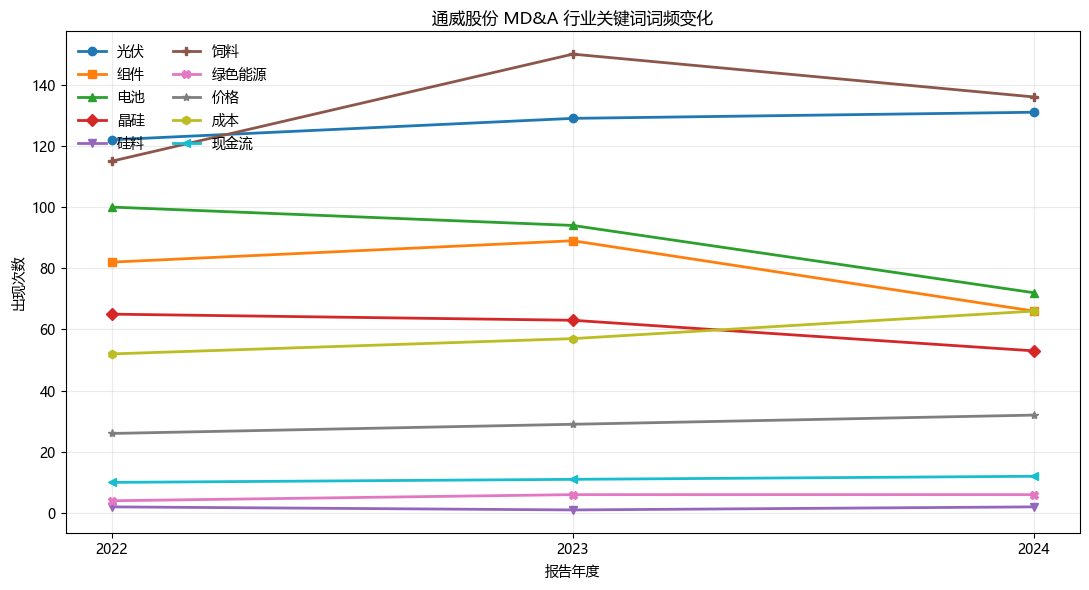

图已保存： c:\Users\ZhuanZ1\Desktop\P03e\figs\fig02_keyword_trend.png


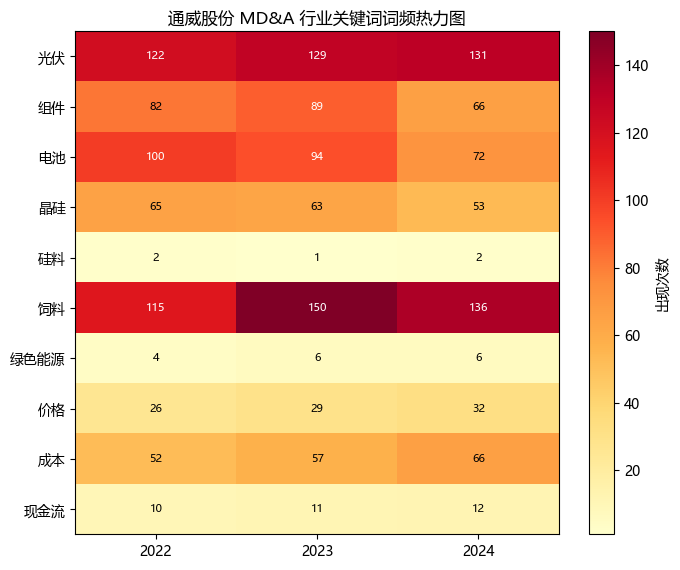

热力图已保存： c:\Users\ZhuanZ1\Desktop\P03e\figs\fig02b_keyword_trend_heatmap.png


In [7]:
trend_keywords = ["光伏", "组件", "电池", "晶硅", "硅料", "饲料", "绿色能源", "价格", "成本", "现金流"]

keyword_trend_rows = []
for year in YEARS:
    text = clean_texts[year]
    chinese_chars = count_chinese(text)
    for keyword in trend_keywords:
        count = text.count(keyword)
        per_10k = count / chinese_chars * 10000 if chinese_chars else 0
        keyword_trend_rows.append({
            "year": year,
            "keyword": keyword,
            "count": count,
            "per_10k_chinese_chars": round(per_10k, 3),
        })

with (DATA_DIR / "keyword_trend.csv").open("w", encoding="utf-8-sig", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["year", "keyword", "count", "per_10k_chinese_chars"])
    writer.writeheader()
    writer.writerows(keyword_trend_rows)

print("关键词趋势（出现次数）")
for keyword in trend_keywords:
    values = [next(r["count"] for r in keyword_trend_rows if r["year"] == year and r["keyword"] == keyword) for year in YEARS]
    print(f"{keyword}: " + "；".join(f"{year}={value}" for year, value in zip(YEARS, values)))

fig, ax = plt.subplots(figsize=(11, 6))
markers = ["o", "s", "^", "D", "v", "P", "X", "*", "h", "<"]
for keyword, marker in zip(trend_keywords, markers):
    values = [next(r["count"] for r in keyword_trend_rows if r["year"] == year and r["keyword"] == keyword) for year in YEARS]
    ax.plot(YEARS, values, marker=marker, linewidth=2, label=keyword)
ax.set_title("通威股份 MD&A 行业关键词词频变化")
ax.set_xlabel("报告年度")
ax.set_ylabel("出现次数")
ax.grid(alpha=0.25)
ax.legend(ncol=2, frameon=False)
fig.tight_layout()
fig_path = FIG_DIR / "fig02_keyword_trend.png"
fig.savefig(fig_path, dpi=180, bbox_inches="tight")
plt.show()
print("图已保存：", fig_path)

# 图 2b：行业关键词词频热力图，更直观对比每个词在三年间的强弱。
trend_matrix = [
    [next(r["count"] for r in keyword_trend_rows if r["year"] == year and r["keyword"] == keyword) for year in YEARS]
    for keyword in trend_keywords
]
draw_heatmap(
    trend_matrix,
    trend_keywords,
    YEARS,
    "通威股份 MD&A 行业关键词词频热力图",
    "出现次数",
    FIG_DIR / "fig02b_keyword_trend_heatmap.png",
    cmap="YlOrRd",
    figsize=(7, 5.8),
)


### 4.1 结果解读

关键词趋势显示，`光伏`三年保持高位并略升（2022=122，2023=129，2024=131），说明新能源业务始终是 MD&A 的核心主题。`饲料`在 2023 年明显上升、2024 年仍处较高水平（115→150→136），反映农牧业务仍是公司重要基本盘。

光伏产业链内部词汇出现分化：`组件、电池、晶硅`在 2024 年有所下降，而 `价格、成本、现金流`连续上升，其中 `成本`从 52 次升至 66 次，`价格`从 26 次升至 32 次。这说明 2024 年文本关注点从单纯描述产业链规模、产品和产能，更多转向价格下行、成本控制和现金流韧性。

结合公司所在行业，2024 年光伏产业链供需失衡、产品价格大幅下跌，管理层在 MD&A 中更频繁讨论价格、成本和经营压力，是比较符合实际经营背景的。

## 5. 风险词汇分析

统计 `风险、不确定、挑战、压力、下滑、下降、亏损、波动、竞争、贸易壁垒` 等负面或压力相关词汇在三年 MD&A 中的出现频次，用于观察管理层对外部环境和经营压力的表述变化。

输出文件：

- `data/risk_words.csv`
- `figs/fig03_risk_words.png`
- `figs/fig03b_risk_words_heatmap.png`

2022: 总计=131；风险=40；不确定=2；挑战=2；压力=12；下滑=0；下降=12；亏损=0；波动=14；竞争=46；贸易壁垒=3
2023: 总计=170；风险=55；不确定=0；挑战=4；压力=5；下滑=1；下降=22；亏损=5；波动=20；竞争=56；贸易壁垒=2
2024: 总计=175；风险=54；不确定=0；挑战=2；压力=8；下滑=2；下降=24；亏损=6；波动=17；竞争=58；贸易壁垒=4


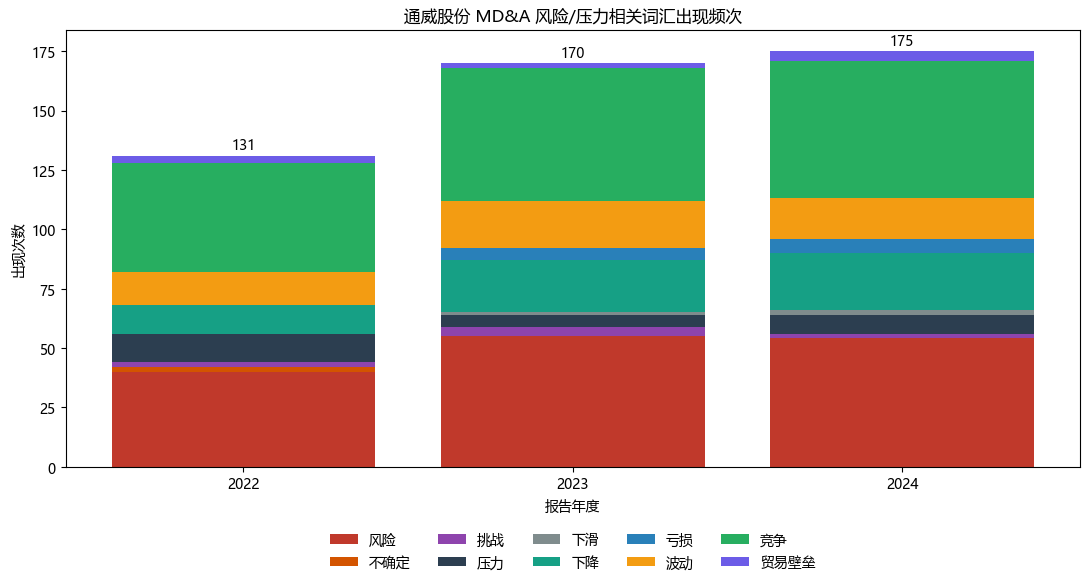

图已保存： c:\Users\ZhuanZ1\Desktop\P03e\figs\fig03_risk_words.png


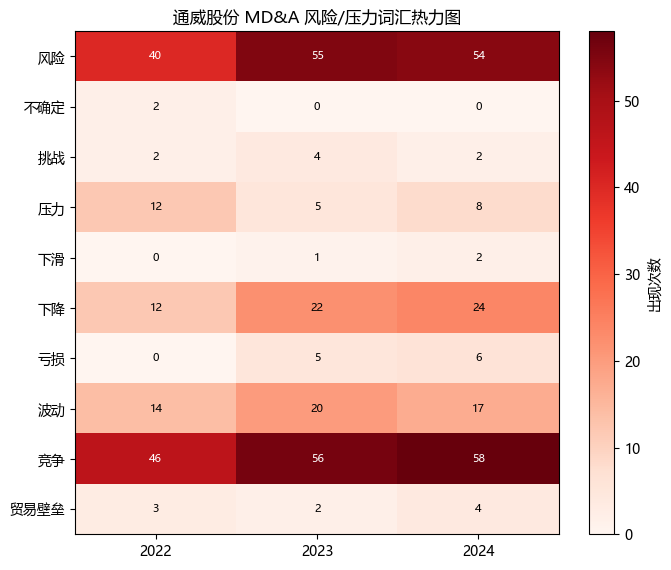

热力图已保存： c:\Users\ZhuanZ1\Desktop\P03e\figs\fig03b_risk_words_heatmap.png


In [8]:
risk_words = ["风险", "不确定", "挑战", "压力", "下滑", "下降", "亏损", "波动", "竞争", "贸易壁垒"]

risk_rows = []
for year in YEARS:
    text = clean_texts[year]
    chinese_chars = count_chinese(text)
    for word in risk_words:
        count = text.count(word)
        per_10k = count / chinese_chars * 10000 if chinese_chars else 0
        risk_rows.append({
            "year": year,
            "word": word,
            "count": count,
            "per_10k_chinese_chars": round(per_10k, 3),
        })

with (DATA_DIR / "risk_words.csv").open("w", encoding="utf-8-sig", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["year", "word", "count", "per_10k_chinese_chars"])
    writer.writeheader()
    writer.writerows(risk_rows)

total_risk = []
for year in YEARS:
    total = sum(r["count"] for r in risk_rows if r["year"] == year)
    total_risk.append(total)
    detail = "；".join(f"{word}={next(r['count'] for r in risk_rows if r['year'] == year and r['word'] == word)}" for word in risk_words)
    print(f"{year}: 总计={total}；{detail}")

x = range(len(YEARS))
fig, ax = plt.subplots(figsize=(11, 6))
bottom = [0] * len(YEARS)
colors = ["#c0392b", "#d35400", "#8e44ad", "#2c3e50", "#7f8c8d", "#16a085", "#2980b9", "#f39c12", "#27ae60", "#6c5ce7"]
for word, color in zip(risk_words, colors):
    values = [next(r["count"] for r in risk_rows if r["year"] == year and r["word"] == word) for year in YEARS]
    ax.bar(YEARS, values, bottom=bottom, label=word, color=color)
    bottom = [b + v for b, v in zip(bottom, values)]
for year, total in zip(YEARS, total_risk):
    ax.text(year, total + 1, str(total), ha="center", va="bottom")
ax.set_title("通威股份 MD&A 风险/压力相关词汇出现频次")
ax.set_xlabel("报告年度")
ax.set_ylabel("出现次数")
ax.legend(ncol=5, frameon=False, bbox_to_anchor=(0.5, -0.12), loc="upper center")
fig.tight_layout()
fig_path = FIG_DIR / "fig03_risk_words.png"
fig.savefig(fig_path, dpi=180, bbox_inches="tight")
plt.show()
print("图已保存：", fig_path)

# 图 3b：风险词汇热力图，显示每类风险/压力表述在各年的集中程度。
risk_matrix = [
    [next(r["count"] for r in risk_rows if r["year"] == year and r["word"] == word) for year in YEARS]
    for word in risk_words
]
draw_heatmap(
    risk_matrix,
    risk_words,
    YEARS,
    "通威股份 MD&A 风险/压力词汇热力图",
    "出现次数",
    FIG_DIR / "fig03b_risk_words_heatmap.png",
    cmap="Reds",
    figsize=(7, 5.8),
)


### 5.1 结果解读

风险/压力相关词汇总频次从 2022 年的 131 次上升到 2023 年的 170 次，并在 2024 年维持高位 175 次，说明近两年管理层对风险、竞争和经营压力的披露强度明显增强。

分词看，`竞争`从 46 次升至 58 次，`下降`从 12 次升至 24 次，`亏损`从 2022 年 0 次升至 2024 年 6 次，`贸易壁垒`在 2024 年也有所增加。这与 2024 年光伏行业阶段性供需失衡、产品价格跌破现金成本、企业普遍亏损以及国际贸易壁垒加剧的背景一致。`风险`一词三年都较高，部分原因是年报风险提示章节具有固定披露格式，因此更值得关注的是 `下降、亏损、竞争、贸易壁垒、压力` 这些更贴近当年经营情境的词。

需要注意的是，风险词频只能说明文本披露强度和关注点变化，不能单独证明风险实际发生程度。后续可以把这些词频结果与收入、毛利率、净利润、行业价格指数等财务或行业数据结合，形成更稳健的解释。

## 6. 任务四：与同行业公司比较（进阶）

本部分选择 `隆基绿能（601012）` 作为同行业对比公司。选择理由：隆基绿能与通威股份同属光伏产业链头部企业，二者都属于新能源制造领域的大体量公司；通威的业务覆盖高纯晶硅、电池、组件及饲料，隆基则更集中于硅片、电池、组件及光伏技术路线，两者既有可比性，也能体现文本风格差异。

为保持比较口径一致，本部分只比较两家公司 `2024 年年度报告` 中的 MD&A 文本。隆基绿能使用巨潮资讯网披露的 2024 年年度报告修订版：`http://static.cninfo.com.cn/finalpage/2025-05-07/1223477802.PDF`。

本任务分三步完成：

1. 简要获取并清洗隆基绿能 2024 年 MD&A。
2. 比较两家公司关键词分布差异。
3. 比较风险表达频次，并判断文本风格是否明显不同。

### 6.1 获取并清洗对比公司文本

这里复用前文 `pdfplumber` 的提取思路，简化数据获取说明：下载隆基绿能 2024 年年度报告修订版，提取“第三节 管理层讨论与分析”至“第四节 公司治理”之前的正文，并使用与通威股份相同思路清洗页眉、页码和表格数字行。

输出文件：

- `data/peer/601012_2024_mda.txt`
- `data/peer/601012_2024_mda_clean.txt`

In [9]:
from pathlib import Path
import csv
import re
import requests
from collections import Counter

import jieba
import pdfplumber
import matplotlib.pyplot as plt
from matplotlib import font_manager

PEER_DIR = DATA_DIR / "peer"
PEER_DIR.mkdir(parents=True, exist_ok=True)

peer_company = {
    "name": "隆基绿能",
    "full_name": "隆基绿能科技股份有限公司",
    "stock_code": "601012",
    "year": "2024",
    "pdf_url": "http://static.cninfo.com.cn/finalpage/2025-05-07/1223477802.PDF",
    "pdf_path": RAW_REPORT_DIR / "601012_2024_annual_report_revised.pdf",
    "raw_txt": PEER_DIR / "601012_2024_mda.txt",
    "clean_txt": PEER_DIR / "601012_2024_mda_clean.txt",
}

headers = {"User-Agent": "Mozilla/5.0", "Referer": "http://www.cninfo.com.cn/"}
if not peer_company["pdf_path"].exists() or peer_company["pdf_path"].stat().st_size < 100_000:
    response = requests.get(peer_company["pdf_url"], headers=headers, timeout=120)
    response.raise_for_status()
    peer_company["pdf_path"].write_bytes(response.content)
    print("隆基绿能 PDF 下载完成：", peer_company["pdf_path"])
else:
    print("隆基绿能 PDF 已存在：", peer_company["pdf_path"])

START_TITLE_COMPACT = "第三节管理层讨论与分析"
END_TITLE_COMPACT = "第四节公司治理"

def peer_compact(text: str) -> str:
    return "".join(text.split())

def peer_loose_pattern(text: str) -> re.Pattern:
    return re.compile(r"\s*".join(re.escape(ch) for ch in text))

def peer_normalize_text(text: str) -> str:
    text = text.replace("\r\n", "\n").replace("\r", "\n")
    text = re.sub(r"[ \t]+\n", "\n", text)
    text = re.sub(r"\n{3,}", "\n\n", text)
    return text.strip()

def extract_peer_mda(pdf_path: Path) -> tuple[str, tuple[int, int]]:
    with pdfplumber.open(pdf_path) as pdf:
        page_texts = [page.extract_text(x_tolerance=1.5, y_tolerance=3) or "" for page in pdf.pages]
    start_candidates = [i for i, text in enumerate(page_texts) if START_TITLE_COMPACT in peer_compact(text)]
    end_candidates = [i for i, text in enumerate(page_texts) if END_TITLE_COMPACT in peer_compact(text)]
    if not start_candidates or not end_candidates:
        raise ValueError("未找到隆基绿能 MD&A 章节边界，请人工检查 PDF。")
    # 隆基年报中目录和正文均包含“第三节”，正文标题在第 10 页之后。
    start_page = next((i for i in start_candidates if i >= 10), start_candidates[-1])
    end_page = next(i for i in end_candidates if i > start_page)
    section_text = "\n\n".join(page_texts[start_page:end_page + 1])
    start_matches = list(peer_loose_pattern(START_TITLE_COMPACT).finditer(section_text))
    start = start_matches[-1].start() if start_matches else 0
    end_match = peer_loose_pattern(END_TITLE_COMPACT).search(section_text, start + 1)
    end = end_match.start() if end_match else len(section_text)
    return peer_normalize_text(section_text[start:end]), (start_page + 1, end_page + 1)

peer_mda, peer_pages = extract_peer_mda(peer_company["pdf_path"])
peer_header = (
    "封面信息\n"
    f"公司名称：{peer_company['full_name']}\n"
    f"股票代码：{peer_company['stock_code']}\n"
    f"报告年度：{peer_company['year']} 年年度报告（修订版）\n"
    "公告来源：巨潮资讯网\n"
    f"原始 PDF：{peer_company['pdf_url']}\n"
    "提取说明：使用 pdfplumber 提取；PDF 为文本型，无需 OCR。\n\n"
)
peer_company["raw_txt"].write_text(peer_header + peer_mda + "\n", encoding="utf-8")
print(f"隆基绿能 MD&A 提取页段：{peer_pages[0]}-{peer_pages[1]}，正文字符数：{len(peer_mda):,}")

# 为了不改动前文 clean_text，这里为同行比较单独定义一个轻量清洗函数。
def peer_strip_to_body(text: str) -> str:
    idx = text.find("第三节 管理层讨论与分析")
    return text[idx:] if idx >= 0 else text

def peer_is_page_noise(line: str) -> bool:
    s = line.strip()
    return bool(
        re.fullmatch(r"[-–—_\s]*\d+[-–—_\s]*", s)
        or re.fullmatch(r"\d+\s*/\s*\d+", s)
        or re.fullmatch(r"(隆基绿能科技股份有限公司|通威股份有限公司\s*)?20\d{2}\s*年年度报告.*", s)
        or re.fullmatch(r"第\s*\d+\s*页\s*/\s*共\s*\d+\s*页", s)
    )

def peer_is_table_noise(line: str) -> bool:
    s = line.strip()
    if not s:
        return False
    if re.fullmatch(r"[□√☑\s]*适用[□√☑\s]*不适用[□√☑\s]*", s):
        return True
    if re.search(r"单位[:：].*(元|万元|亿元).*币种[:：]", s):
        return True
    no_space = re.sub(r"\s+", "", s)
    if len(no_space) < 12:
        return False
    chinese = len(re.findall(r"[\u4e00-\u9fff]", no_space))
    digits = len(re.findall(r"[0-9０-９]", no_space))
    numeric_punct = len(re.findall(r"[0-9０-９,，.．%％+\-－()/（）]", no_space))
    ratio = numeric_punct / max(len(no_space), 1)
    return (digits >= 8 and chinese <= 6) or (ratio >= 0.58 and chinese <= 12)

def peer_is_heading(line: str) -> bool:
    return bool(re.match(r"^(第[一二三四五六七八九十]+节|[一二三四五六七八九十]+、|（[一二三四五六七八九十]+）|\([一二三四五六七八九十]+\)|\d+[、.．])", line.strip()))

def peer_clean_text(raw: str) -> str:
    body = peer_strip_to_body(raw).replace("\ufeff", "").replace("\f", "\n").replace("\u3000", " ")
    body = re.sub(r"[\t\r]+", " ", body)
    kept = []
    for line in body.splitlines():
        line = re.sub(r"\s+", " ", line).strip()
        if not line:
            kept.append("")
            continue
        if peer_is_page_noise(line) or peer_is_table_noise(line):
            continue
        kept.append(line)

    paragraphs = []
    buf = ""
    for line in kept:
        if not line:
            if buf:
                paragraphs.append(buf)
                buf = ""
            continue
        if peer_is_heading(line):
            if buf:
                paragraphs.append(buf)
            paragraphs.append(line)
            buf = ""
            continue
        if not buf:
            buf = line
        elif not re.search(r"[。！？；：]$", buf):
            buf += (" " if re.search(r"[A-Za-z0-9]$", buf) and re.match(r"^[A-Za-z0-9]", line) else "") + line
        else:
            paragraphs.append(buf)
            buf = line
    if buf:
        paragraphs.append(buf)
    return re.sub(r"\n{3,}", "\n\n", "\n".join(p.strip() for p in paragraphs if p.strip())).strip() + "\n"

peer_cleaned = peer_clean_text(peer_company["raw_txt"].read_text(encoding="utf-8"))
peer_company["clean_txt"].write_text(peer_cleaned, encoding="utf-8")
print("隆基绿能清洗后字符数：", len(peer_cleaned), "中文字符数：", count_chinese(peer_cleaned))

隆基绿能 PDF 已存在： c:\Users\ZhuanZ1\Desktop\P03e\data\raw_reports\601012_2024_annual_report_revised.pdf
隆基绿能 MD&A 提取页段：16-44，正文字符数：24,281
隆基绿能清洗后字符数： 19215 中文字符数： 13981


### 6.2 关键词分布差异

这一部分比较通威股份与隆基绿能 2024 年 MD&A 的关键词 Top 30，并绘制关键词分布热力图。图中纵轴为两家公司 Top 词并集，横轴为公司，数值为该词在对应公司 MD&A 中的出现次数。

输出文件：

- `data/peer_keyword_top30.csv`
- `figs/fig04_peer_keyword_heatmap.png`

关键词 Top 15 对比
通威股份: 光伏(131)；企业(94)；饲料(92)；技术(85)；全球(64)；养殖(62)；组件(61)；研发(59)；成本(58)；产业(55)；风险(52)；产能(46)；增长(45)；期内(45)；优势(40)
隆基绿能: 光伏(112)；技术(81)；组件(73)；全球(54)；电池(46)；硅片(37)；研发(37)；项目(32)；BC(31)；产能(30)；分析(28)；说明(28)；能力(27)；成本(27)；领先(27)


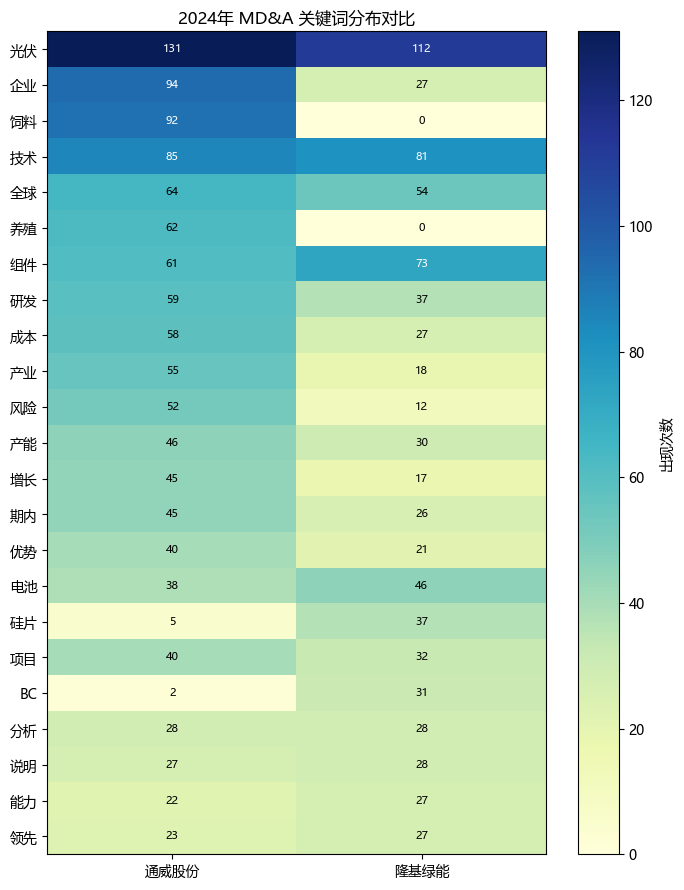

热力图已保存： c:\Users\ZhuanZ1\Desktop\P03e\figs\fig04_peer_keyword_heatmap.png


In [10]:
peer_texts = {
    "通威股份": (CLEAN_DIR / "600438_2024_mda_clean.txt").read_text(encoding="utf-8"),
    "隆基绿能": peer_company["clean_txt"].read_text(encoding="utf-8"),
}

peer_stopwords = set(stopwords) if "stopwords" in globals() else {
    "公司", "报告", "报告期", "年度", "情况", "进行", "实现", "持续", "进一步", "相关", "主要", "方面",
    "以及", "同时", "通过", "不断", "提升", "保持", "其中", "具有", "形成", "推动", "加强", "开展",
    "业务", "产品", "市场", "行业", "客户", "生产", "销售", "发展", "建设", "管理", "经营", "影响", "同比",
    "万元", "亿元", "适用", "不适用", "股份", "上市公司", "有限", "一", "二", "三", "四", "五", "六", "七", "八", "九", "十", "年", "月", "日", "和", "与", "及", "等", "在", "对", "为", "以", "的", "了", "是", "将", "也", "并", "中", "上", "下"
}

for word in ["光伏", "高纯晶硅", "太阳能电池", "产业链", "电池片", "组件", "硅料", "饲料", "单晶硅片", "BC电池", "HPBC", "TOPCon", "现金流", "贸易壁垒", "技术研发"]:
    jieba.add_word(word)

def peer_tokenize(text: str) -> list[str]:
    tokens = []
    for token in jieba.lcut(text):
        token = token.strip()
        if len(token) < 2 or token in peer_stopwords:
            continue
        if re.fullmatch(r"[0-9０-９.,，.%％/\-]+", token):
            continue
        if not re.search(r"[\u4e00-\u9fffA-Za-z]", token):
            continue
        tokens.append(token)
    return tokens

peer_freq = {company: Counter(peer_tokenize(text)) for company, text in peer_texts.items()}
peer_keyword_rows = []
for company in ["通威股份", "隆基绿能"]:
    for rank, (word, count) in enumerate(peer_freq[company].most_common(30), start=1):
        peer_keyword_rows.append({"company": company, "rank": rank, "word": word, "count": count})

with (DATA_DIR / "peer_keyword_top30.csv").open("w", encoding="utf-8-sig", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["company", "rank", "word", "count"])
    writer.writeheader()
    writer.writerows(peer_keyword_rows)

print("关键词 Top 15 对比")
for company in ["通威股份", "隆基绿能"]:
    pairs = "；".join(f"{word}({count})" for word, count in peer_freq[company].most_common(15))
    print(f"{company}: {pairs}")

peer_heatmap_words = []
for company in ["通威股份", "隆基绿能"]:
    for word, _ in peer_freq[company].most_common(15):
        if word not in peer_heatmap_words:
            peer_heatmap_words.append(word)
peer_heatmap_words = peer_heatmap_words[:24]
peer_keyword_matrix = [
    [peer_freq[company].get(word, 0) for company in ["通威股份", "隆基绿能"]]
    for word in peer_heatmap_words
]

draw_heatmap(
    peer_keyword_matrix,
    peer_heatmap_words,
    ["通威股份", "隆基绿能"],
    "2024年 MD&A 关键词分布对比",
    "出现次数",
    FIG_DIR / "fig04_peer_keyword_heatmap.png",
    cmap="YlGnBu",
    figsize=(7, 9),
)

### 6.2 结果解读

两家公司都高度聚焦 `光伏、组件、技术、全球、研发、成本` 等词，说明二者同属光伏制造龙头，MD&A 的共同主线是产业链竞争、技术路线和全球市场。

差异也比较明显：通威股份的 `饲料、养殖、高纯晶硅、产业链、风险` 更突出，反映其“绿色农业 + 绿色能源”的双主业结构，以及上游高纯晶硅和一体化产业链特征；隆基绿能的 `硅片、BC、组件、电池、领先、能力` 更突出，说明其文本更集中于光伏产品、技术路线和制造能力。简单说，通威的关键词分布更“多业务 + 产业链纵深”，隆基更“光伏制造 + 技术路线集中”。

### 6.3 风险表达频次与文本风格差异

这一部分沿用前文风险词表，比较两家公司 2024 年风险/压力相关词汇出现频次。为了避免文本长度差异影响判断，表中同时保存每万中文字符出现次数。

输出文件：

- `data/peer_risk_words.csv`
- `figs/fig05_peer_risk_heatmap.png`

通威股份: 风险词总频次=175；风险=54；不确定=0；挑战=2；压力=8；下滑=2；下降=24；亏损=6；波动=17；竞争=58；贸易壁垒=4
隆基绿能: 风险词总频次=98；风险=13；不确定=3；挑战=6；压力=3；下滑=4；下降=25；亏损=10；波动=2；竞争=27；贸易壁垒=5


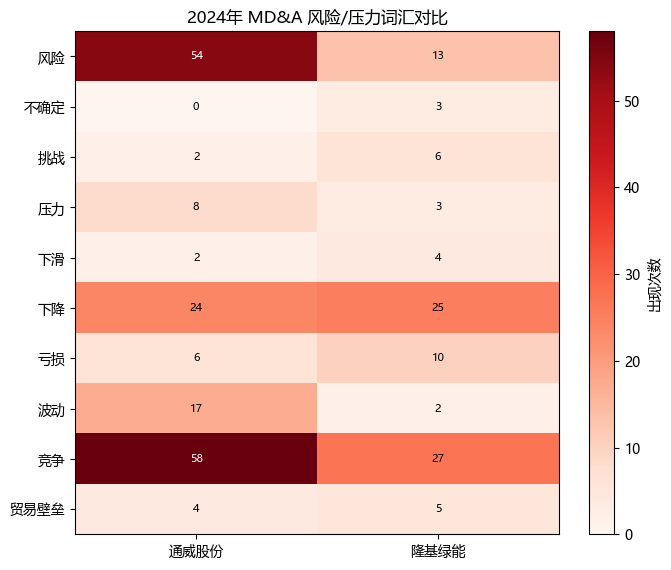

热力图已保存： c:\Users\ZhuanZ1\Desktop\P03e\figs\fig05_peer_risk_heatmap.png


In [11]:
peer_risk_words = ["风险", "不确定", "挑战", "压力", "下滑", "下降", "亏损", "波动", "竞争", "贸易壁垒"]
peer_risk_rows = []
for company, text in peer_texts.items():
    chinese_chars = count_chinese(text)
    for word in peer_risk_words:
        count = text.count(word)
        peer_risk_rows.append({
            "company": company,
            "word": word,
            "count": count,
            "per_10k_chinese_chars": round(count / chinese_chars * 10000, 3) if chinese_chars else 0,
        })

with (DATA_DIR / "peer_risk_words.csv").open("w", encoding="utf-8-sig", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["company", "word", "count", "per_10k_chinese_chars"])
    writer.writeheader()
    writer.writerows(peer_risk_rows)

for company in ["通威股份", "隆基绿能"]:
    total = sum(row["count"] for row in peer_risk_rows if row["company"] == company)
    detail = "；".join(f"{word}={next(row['count'] for row in peer_risk_rows if row['company'] == company and row['word'] == word)}" for word in peer_risk_words)
    print(f"{company}: 风险词总频次={total}；{detail}")

peer_risk_matrix = [
    [next(row["count"] for row in peer_risk_rows if row["company"] == company and row["word"] == word) for company in ["通威股份", "隆基绿能"]]
    for word in peer_risk_words
]

draw_heatmap(
    peer_risk_matrix,
    peer_risk_words,
    ["通威股份", "隆基绿能"],
    "2024年 MD&A 风险/压力词汇对比",
    "出现次数",
    FIG_DIR / "fig05_peer_risk_heatmap.png",
    cmap="Reds",
    figsize=(7, 5.8),
)

### 6.3 结果解读

2024 年通威股份风险词总频次为 175 次，隆基绿能为 98 次。通威股份在 `风险、竞争、波动、压力` 等词上更高，说明其 MD&A 风险披露篇幅和覆盖面更强；这可能与其业务更分散、同时涉及农牧和光伏两大板块有关，也与 2024 年光伏产业链价格下行、公司盈利承压背景有关。

隆基绿能虽然总风险词频较低，但 `下降、亏损、贸易壁垒、不确定、挑战` 的相对表达并不弱，尤其 `下降` 和 `亏损` 在每万中文字符口径下较突出，说明其文本更集中地讨论光伏制造环节在 2024 年面对的盈利压力、技术路线竞争和国际贸易环境。

综合来看，两家公司文本风格有明显差异：通威股份的 MD&A 更像“多业务经营复盘 + 风险提示”，覆盖农牧、晶硅、电池组件、现金流和供应链；隆基绿能的 MD&A 更像“光伏制造与技术路线叙事”，重点围绕组件、电池、硅片、BC 技术和全球竞争展开。二者同受光伏行业周期影响，但通威文本更综合，隆基文本更技术集中。